In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [117]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,            # base font size
    "axes.labelsize": 14,       # x/y labels
    "axes.titlesize": 14,       # title
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.dpi": 300
})

In [118]:
def standardize(flare_data):
  median = []
  std = []
  flare_data = np.array(flare_data)
  n_elements = flare_data.shape[0]
  for j in range(flare_data.shape[1]):
    standard_deviation_of_this_feature = np.std(flare_data[:, j])
    median_of_this_feature = np.median(flare_data[:, j])
    std.append(standard_deviation_of_this_feature)
    median.append(median_of_this_feature)
    for i in range(n_elements):
        flare_data[i, j] = (flare_data[i, j] - median_of_this_feature) / (standard_deviation_of_this_feature)
  return flare_data, median, std

def fit_data(flare_data, median, std):
    flare_data = np.array(flare_data)
    for j in range(flare_data.shape[1]):
        flare_data[:, j] = (flare_data[:, j] - median[j]) / std[j]
    return flare_data

In [119]:
data = pd.read_csv("ordered_features.csv")
data.head(5)

,MEANGBZ,MEANGBT,MEANGBT_PIL,MEANGBH_PIL,MEANGBZ_PIL,MEANGBH,SAVNCPP,ABSNJZH,MEANJZH_PIL,MEANALP,...,MEANGAM,MEANJZD_PIL,TOTPOT,AREA_ACR,USFLUX,MEANPOT_PIL,MEANPOT,SHRGT45_PIL,MEANSHR_PIL,CME
0,101.466,93.429,103.378490,83.663602,123.976481,68.471,9.554389e+12,558.116,0.039422,0.030222,...,60.629,-0.133815,8.171862e+23,1078.161865,2.416427e+22,23064.327604,15371.740,61.000373,54.056748,1.0
1,101.450,96.645,101.434660,72.499857,117.829900,61.270,9.006182e+12,186.149,-0.034703,-0.010615,...,53.676,0.544844,5.367295e+23,946.170837,2.316485e+22,15625.577819,11578.920,57.148718,51.244767,1.0
2,94.534,85.268,84.794282,55.856795,104.850290,45.785,1.857044e+13,255.077,0.008317,0.006022,...,39.556,0.272568,1.046693e+24,1927.615967,6.534931e+22,16094.083512,8713.998,44.568611,44.424355,1.0
3,107.913,106.978,103.543487,63.343866,123.276868,43.043,1.961166e+13,342.725,0.051762,0.028216,...,31.113,-1.582965,1.577271e+23,835.504700,2.467217e+22,9464.487325,3060.831,40.000000,44.524406,1.0
4,118.732,108.482,108.975338,82.285251,132.599034,69.981,3.979348e+13,1053.375,0.081813,0.068432,...,52.421,1.073877,5.587943e+23,1273.788696,2.197264e+22,18780.627285,12412.300,55.779889,50.635565,1.0


In [120]:
data.shape

(408, 35)

In [121]:
pos = data[data["CME"]==1]
neg = data[data["CME"]==0]

In [122]:
data.columns

Index(['MEANGBZ', 'MEANGBT', 'MEANGBT_PIL', 'MEANGBH_PIL', 'MEANGBZ_PIL',
       'MEANGBH', 'SAVNCPP', 'ABSNJZH', 'MEANJZH_PIL', 'MEANALP',
       'MEANALP_PIL', 'MEANJZH', 'TOTUSJH_PIL', 'TOTUSJZ_PIL', 'TOTPOT_PIL',
       'R_VALUE', 'SAVNCPP_PIL', 'ABSNJZH_PIL', 'SHRGT45', 'TOTUSJH',
       'MEANSHR', 'MEANGAM_PIL', 'MEANJZD', 'USFLUX_PIL', 'TOTUSJZ', 'MEANGAM',
       'MEANJZD_PIL', 'TOTPOT', 'AREA_ACR', 'USFLUX', 'MEANPOT_PIL', 'MEANPOT',
       'SHRGT45_PIL', 'MEANSHR_PIL', 'CME'],
      dtype='object')

In [123]:
normal_parms = [x for x in data.columns if not x.endswith("_PIL")]
data = data[normal_parms]


In [124]:
normal_parms

['MEANGBZ',
 'MEANGBT',
 'MEANGBH',
 'SAVNCPP',
 'ABSNJZH',
 'MEANALP',
 'MEANJZH',
 'R_VALUE',
 'SHRGT45',
 'TOTUSJH',
 'MEANSHR',
 'MEANJZD',
 'TOTUSJZ',
 'MEANGAM',
 'TOTPOT',
 'AREA_ACR',
 'USFLUX',
 'MEANPOT',
 'CME']

In [125]:
X = data.drop('CME',axis = 1)
y = data["CME"]

In [126]:
columns = X.columns
X,median,std = standardize(X)

In [127]:
data.shape

(408, 19)

In [128]:
from sklearn.feature_selection import f_classif
from sklearn.datasets import make_classification

from sklearn.feature_selection import SelectKBest, f_classif

N_features = 35

selector = SelectKBest(f_classif, k=N_features)
selector.fit(X, y)
scores = selector.scores_
print(scores)

[11.93120173  9.14474871  4.43328995  4.42988617  4.38724204  3.99255767
  2.52463125  1.56243405  1.04720366  0.79909676  0.63781612  0.51109042
  0.28150464  0.2254132   0.21274312  0.09670161  0.08890496  0.01366486]


c:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:783: UserWarning: k=35 is greater than n_features=18. All the features will be returned.
  warnings.warn(


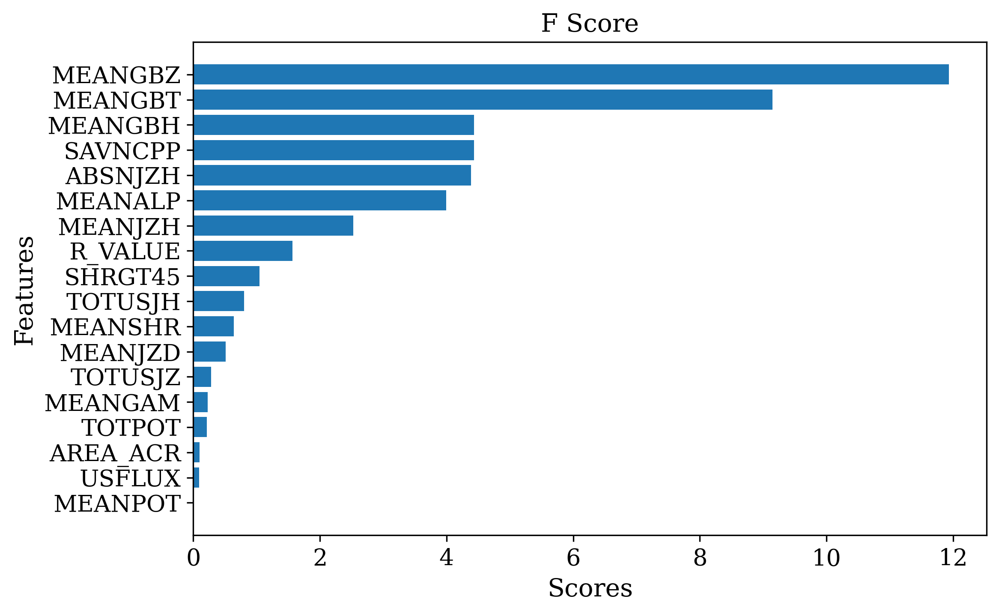

In [129]:
import matplotlib.pyplot as plt
import pandas as pd

feature_names = columns
scores_df = pd.DataFrame({'Feature': feature_names, 'Score': scores}).sort_values('Score', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(scores_df['Feature'], scores_df['Score'])
plt.xlabel('Scores')
plt.ylabel('Features')
plt.title('F Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

ordered_features = scores_df['Feature'].tolist()

In [130]:
min_a = pos.index.min()
max_a = pos.index.max()

pos['normalized_event_number'] = (pos.index - min_a) / (max_a - min_a)

min_b = neg.index.min()
max_b = neg.index.max()

neg['normalized_event_number'] = (neg.index - min_b) / (max_b - min_b)

In [131]:
import numpy as np
import matplotlib.pyplot as plt

a = 1
plt.figure(figsize=(16, 90),dpi = 300)

for i in range(len(feature_names) - 1):
    mean_pos = np.mean(pos.iloc[:, i])
    mean_neg = np.mean(neg.iloc[:, i])
    std_pos = np.std(pos.iloc[:,i])
    std_neg = np.std(neg.iloc[:,i])

    plt.subplot(len(feature_names), 2, a)
    plt.scatter(pos["normalized_event_number"], pos.iloc[:, i], alpha=0.7, label="Positive (Eruptive Flares)")
    plt.scatter(neg["normalized_event_number"], neg.iloc[:, i], alpha=0.7, label="Negative (Confined Flares)")
    plt.axhline(mean_pos, color='b', ls='-', label=f"Mean($\\mu$) Pos: {mean_pos:.2f}")
    plt.axhline(mean_neg, color='r', ls='--', label=f"Mean($\\mu$) Neg: {mean_neg:.2f}")
    plt.xlabel("Normalized Event Number")
    plt.ylabel(ordered_features[i])
    plt.legend()

    plt.subplot(len(feature_names), 2, a + 1)
    plt.hist(pos.iloc[:, i], bins=20, density=True, alpha=0.7)
    plt.hist(neg.iloc[:, i], bins=20, density=True, alpha=0.7)
    plt.axvline(mean_pos, color='b',ls='-', label=f"Mean($\\mu$) Pos: {mean_pos:.2f}")
    plt.axvline(mean_neg, color='r',ls='--', label=f"Mean($\\mu$) Neg: {mean_neg:.2f}")
    ymin, ymax = plt.ylim()
    plt.fill_betweenx([ymin, ymax], mean_pos - std_pos, mean_pos + std_pos, color='b', alpha=0.2,label=f'Stdev($\\sigma$) Pos: {std_pos:.2f}')
    plt.fill_betweenx([ymin, ymax], mean_neg - std_neg, mean_neg + std_neg, color='r', alpha=0.2, label=f'Stdev($\\sigma$) Neg: {std_neg:.2f}')
    plt.xlabel(ordered_features[i])
    plt.ylabel('Probability Density')
    plt.legend()

    a += 2

plt.tight_layout()
plt.show()
plt.savefig("2016_parameters_pdf.png")

<Figure size 1920x1440 with 0 Axes>

In [132]:
from sklearn.model_selection import StratifiedKFold
from sklearn import svm
from sklearn.metrics import confusion_matrix

In [133]:
def standardize(flare_data):
  median = []
  std = []
  flare_data = np.array(flare_data)
  n_elements = flare_data.shape[0]
  for j in range(flare_data.shape[1]):
    standard_deviation_of_this_feature = np.std(flare_data[:, j])
    median_of_this_feature = np.median(flare_data[:, j])
    std.append(standard_deviation_of_this_feature)
    median.append(median_of_this_feature)
    for i in range(n_elements):
        flare_data[i, j] = (flare_data[i, j] - median_of_this_feature) / (standard_deviation_of_this_feature)
  return flare_data, median, std

def fit_data(flare_data, median, std):
    flare_data = np.array(flare_data)
    for j in range(flare_data.shape[1]):
        flare_data[:, j] = (flare_data[:, j] - median[j]) / std[j]
    return flare_data

In [134]:
data = pd.read_csv("ordered_features.csv")
columns = data.columns.tolist()

pil_parameters = [i for i in columns if i.endswith("_PIL")]
param = [i for i in columns if i not in pil_parameters and i != "CME"]

In [135]:
tss_mean = []
tss_std = []
param_C = []
param_gamma = []
for C in [1e-3, 1e-2, 1e-1, 1, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6]:
    for gamma in [1, 0.1, 0.01, 0.07, 0.001, 0.005, 0.0001]:
        skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
        tss_scores = []

        for train_index, test_index in skf.split(X, y):
            xtrain, xtest = X[train_index], X[test_index]
            ytrain, ytest = y[train_index], y[test_index]

            xtrain_norm, median, std = standardize(xtrain)
            xtest_norm = fit_data(xtest, median, std)

            clf = svm.SVC(class_weight="balanced", C=C, gamma=gamma, kernel='rbf', probability=True)
            clf.fit(xtrain_norm, ytrain)
            ypred = clf.predict(xtest_norm)

            TN, FP, FN, TP = confusion_matrix(ytest, ypred).ravel()

            if (TP + FN == 0 or FP + TN == 0):
                tss_scores.append(np.nan)
                continue

            # TSS
            tss = TP / (TP + FN) - FP / (FP + TN)
            tss_scores.append(tss)

        # Store average scores
        tss_mean.append(round(np.nanmean(tss_scores), 4))
        tss_std.append(round(np.nanstd(tss_scores), 4))
        param_C.append(C)
        param_gamma.append(gamma)

        print(f"Completed with C={C} and gamma={gamma}")


Completed with C=0.001 and gamma=1
Completed with C=0.001 and gamma=0.1
Completed with C=0.001 and gamma=0.01
Completed with C=0.001 and gamma=0.07
Completed with C=0.001 and gamma=0.001
Completed with C=0.001 and gamma=0.005
Completed with C=0.001 and gamma=0.0001
Completed with C=0.01 and gamma=1
Completed with C=0.01 and gamma=0.1
Completed with C=0.01 and gamma=0.01
Completed with C=0.01 and gamma=0.07
Completed with C=0.01 and gamma=0.001
Completed with C=0.01 and gamma=0.005
Completed with C=0.01 and gamma=0.0001
Completed with C=0.1 and gamma=1
Completed with C=0.1 and gamma=0.1
Completed with C=0.1 and gamma=0.01
Completed with C=0.1 and gamma=0.07
Completed with C=0.1 and gamma=0.001
Completed with C=0.1 and gamma=0.005
Completed with C=0.1 and gamma=0.0001
Completed with C=1 and gamma=1
Completed with C=1 and gamma=0.1
Completed with C=1 and gamma=0.01
Completed with C=1 and gamma=0.07
Completed with C=1 and gamma=0.001
Completed with C=1 and gamma=0.005
Completed with C=1 an

In [136]:
tss_df = pd.DataFrame({
    "C": param_C,
    "gamma": param_gamma,
    "tss_mean": tss_mean,
    "tss_std": tss_std
})

In [137]:
best_tss_row = tss_df.loc[tss_df['tss_mean'].idxmax()]
print(best_tss_row)

C           1000.0000
gamma          0.0001
tss_mean       0.3498
tss_std        0.1682
Name: 48, dtype: float64


In [138]:
from sklearn import svm
number_of_examples = data.shape[0]
C = best_tss_row['C']
gamma = best_tss_row['gamma']
class_weight = "balanced"
clf = svm.SVC(C=C, gamma=gamma, kernel='rbf', class_weight=class_weight,cache_size=500, max_iter=-1, shrinking=True, tol=1e-8, probability=True)

In [139]:
def confusion_table(pred, labels):
    """
    computes the number of TP, TN, FP, FN events given the arrays with predictions and true labels
    and returns the true skill score

    Args:
    pred: np array with predictions (1 for flare, 0 for nonflare)
    labels: np array with true labels (1 for flare, 0 for nonflare)

    Returns: true negative, false positive, true positive, false negative
    """
    Nobs = len(pred)
    TN = 0.
    TP = 0.
    FP = 0.
    FN = 0.
    for i in range(Nobs):
        if (pred[i] == 0 and labels[i] == 0):
            TN += 1
        elif (pred[i] == 1 and labels[i] == 0):
            FP += 1
        elif (pred[i] == 1 and labels[i] == 1):
            TP += 1
        elif (pred[i] == 0 and labels[i] == 1):
            FN += 1
        else:
            print("Error! Observation could not be classified.")
    return TN, FP, TP, FN

In [140]:
from sklearn.model_selection import StratifiedKFold

# lists to hold the TSS and standard deviation of the TSS
array_of_avg_TSS = np.ndarray([50])
array_of_std_TSS = np.ndarray([50])

# xdata are the examples
# ydata are the labels
xdata = X
ydata = np.array(y)

# compute the TSS for a variety of k ranging from 2 to 52
# this is to see how the TSS varies as a function of k, and to test if k=10 really makes sense
for k in range(2, 52):
    skf = StratifiedKFold(n_splits=k, shuffle=True,random_state=42)
    these_TSS_for_this_k = []
    for train_index, test_index in skf.split(xdata, ydata):
        xtrain, xtest = X[train_index], X[test_index]
        ytrain, ytest = y[train_index], y[test_index]

        xtrain_norm, median, std = standardize(xtrain)
        xtest_norm = fit_data(xtest, median, std)

        clf.fit(xtrain_norm, ytrain)
        TN, FP, FN, TP = confusion_matrix(clf.predict(xtest_norm), ytest).ravel()
        if (((TP+FN) == 0.0) or (FP+TN) == 0.0):
            these_TSS_for_this_k.append(np.nan)
            continue
        else:
            these_TSS_for_this_k.append(TP/(TP+FN) - FP/(FP+TN))
    TSS_k = np.array(these_TSS_for_this_k)
    array_of_avg_TSS[k-2] = np.mean(TSS_k)
    array_of_std_TSS[k-2] = np.std(TSS_k)

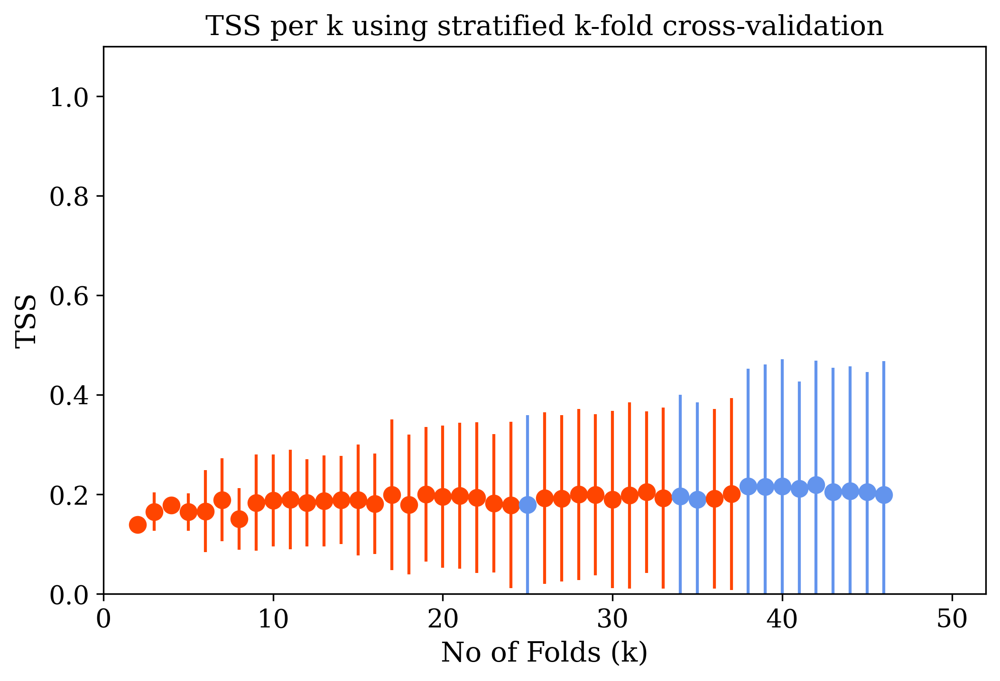

In [141]:
fig, ax = plt.subplots(figsize=(8, 5),dpi = 300)      # define the size of the figure
orangered = (1.0, 0.27, 0, 1.0)              # create an orange-red color
cornblue = (0.39, 0.58, 0.93, 1.0)           # create a cornflower-blue color

# define some style elements
marker_style_red = dict(linestyle='', markersize=8,
                        fillstyle='full', color=orangered, markeredgecolor=orangered)
marker_style_blue = dict(linestyle='', markersize=8,
                         fillstyle='full', color=cornblue, markeredgecolor=cornblue)

# ascribe the data to the axes
k = np.arange(50)+2
for i in range(50):
    if (array_of_avg_TSS[i] > array_of_std_TSS[i]):
        ax.errorbar(k[i], array_of_avg_TSS[i],yerr=array_of_std_TSS[i], linestyle='', color=orangered)
        ax.plot(k[i], array_of_avg_TSS[i], 'o', **marker_style_red)
    if (array_of_avg_TSS[i] <= array_of_std_TSS[i]):
        ax.errorbar(k[i], array_of_avg_TSS[i],yerr=array_of_std_TSS[i], linestyle='', color=cornblue)
        ax.plot(k[i], array_of_avg_TSS[i], 'o', **marker_style_blue)

# set plot limits
plt.xlim(xmax=52, xmin=0)
plt.ylim(ymax=1.1, ymin=0)

# label the axes and the plot
ax.set_xlabel('No of Folds (k)')
ax.set_ylabel('TSS')
plt.title(r'TSS per k using stratified k-fold cross-validation')
fig = plt.gcf()

In [142]:
# For all parameters, the TSS is:
print("The TSS equals", array_of_avg_TSS[9],"plus or minus", array_of_std_TSS[9], ".")

The TSS equals 0.1895955476915841 plus or minus 0.09978577852130832 .
